Portfolio #4 - Aspect-Based Sentiment Analysis (ABSA) for Indonesian Perfume Reviews

## Notebook Objective

This notebook aims to understand the characteristics, quality, and textual patterns of customer reviews before developing an Aspect-Based Sentiment Analysis (ABSA) model. It includes data quality assessment, data cleaning, text preprocessing, and exploratory text analysis to ensure the dataset is reliable for annotation and model development.

# Sprint 1 - Business Understanding & Data Quality Assessment

**Objective**

Understand the scraped Tokopedia perfume review dataset before building the ABSA pipeline.

## 1. Load Dataset

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
DATA_PATH = "/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/data/raw/perfume_review_raw.csv"

In [25]:
PROJECT_PATH = "/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume"

## 2. Dataset Overview

This section provides a high-level overview of the scraped perfume review dataset, including the number of observations, features, and data types.

In [26]:
raw_df = pd.read_csv(DATA_PATH)

raw_df.head()

,brand,product,username,rating,tanggal,review
0,HMNS,Philea,J***a,5,3 bulan lalu,"Wanginya pas buat saya..elegant, ringan, seger..."
1,HMNS,Philea,Z***f,5,10 bulan lalu,Fix ini parfum hmns terbaik terenak terdebes. ...
2,HMNS,Philea,F***m,5,7 bulan lalu,"produk sesuai deskripsi, produk berkualitas, h..."
3,HMNS,Philea,Q***z,5,3 minggu lalu,"pengiriman aman dan cepat, belanja dapet harga..."
4,HMNS,Philea,shabrina,5,10 bulan lalu,"packing aman banget, wangi ny bener2 se enakk ..."


In [27]:
print(f"Rows    : {raw_df.shape[0]}")
print(f"Columns : {raw_df.shape[1]}")

raw_df.info()

Rows    : 5589
Columns : 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5589 entries, 0 to 5588
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   brand     5589 non-null   object
 1   product   5589 non-null   object
 2   username  5589 non-null   object
 3   rating    5589 non-null   int64 
 4   tanggal   5589 non-null   object
 5   review    5579 non-null   object
dtypes: int64(1), object(5)
memory usage: 262.1+ KB


## 3. Data Quality Assessment

Before developing the ABSA model, the dataset is assessed for missing values, duplicate records, and potential data quality issues.

In [37]:
raw_df.isna().sum()

,0
brand,0
product,0
username,0
rating,0
tanggal,0
review,10
review_length,0


**Observation**

Only 10 reviews (0.18%) contain missing review text.

Since the percentage is negligible and review text is the primary input for ABSA, these records will be removed during preprocessing.

In [38]:
raw_df.duplicated(subset=["review"]).sum()

np.int64(43)

In [39]:
duplicate_reviews = raw_df[raw_df.duplicated(subset=["review"], keep=False)]

duplicate_reviews.sort_values("review").head()

,brand,product,username,rating,tanggal,review,review_length
2917,SAFF&CO,Ostara,R***y,5,10 bulan lalu,"Barang bagus sesuai deskripsi, pengiriman dan ...",62
3171,SAFF&CO,Irai Leima,R***y,5,10 bulan lalu,"Barang bagus sesuai deskripsi, pengiriman dan ...",62
4164,MYKONOS,Enchanted,M***e,5,Lebih dari 1 tahun lalu,"Gila, berasa punya parfum mewah euy Packaging ...",70
4733,MYKONOS,Utopia,A***p,5,Lebih dari 1 tahun lalu,"Gila, berasa punya parfum mewah euy Packaging ...",70
4959,MYKONOS,Utopia,L***a,5,2 bulan lalu,Kualitas produk: Bagussss packaging aman thank...,58


**Observation**

Although 43 duplicated review texts were detected, they originate from different users and products. Therefore, they are treated as independent customer opinions rather than duplicated records.

In [40]:
raw_df["rating"].value_counts().sort_index()

,count
rating,
1,1
3,10
4,90
5,5488


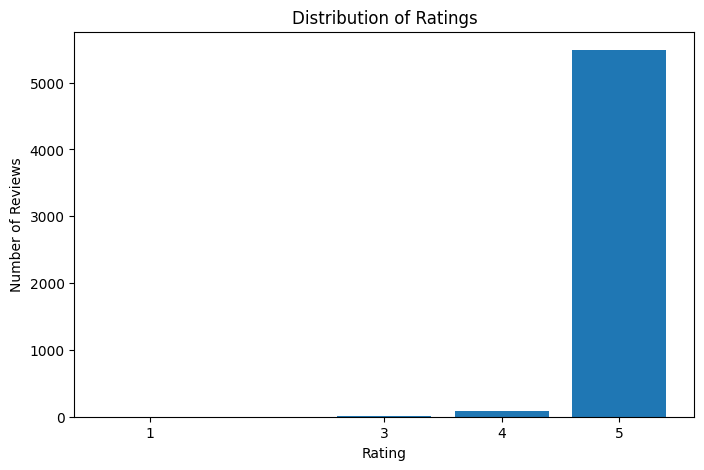

In [41]:
rating_counts = raw_df["rating"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    rating_counts.index,
    rating_counts.values
)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.xticks(rating_counts.index)

plt.show()

**Business Implication**

Overall ratings alone are insufficient to identify product weaknesses because even highly rated reviews may contain negative opinions on specific aspects (e.g., longevity). This finding justifies the use of Aspect-Based Sentiment Analysis (ABSA) instead of relying solely on star ratings.

In [42]:
raw_df["brand"].value_counts()

,count
brand,
HMNS,2049
MYKONOS,1785
SAFF&CO,1755


In [43]:
raw_df["product"].value_counts()

,count
product,
Farhampton,300
ORGSM,300
Alpha,300
Elea,300
California Blue,300
Essence of the Sun,300
Unrosed,300
Pink Drops,300
Utopia,300


In [44]:
raw_df["review_length"] = raw_df["review"].fillna("").str.len()

raw_df["review_length"].describe()

,review_length
count,5589.000000
mean,121.572016
std,141.154219
min,0.000000
25%,60.000000
50%,92.000000
75%,149.000000
max,7786.000000


In [45]:
longest_idx = raw_df["review_length"].idxmax()

longest_review = raw_df.loc[longest_idx]

print("Row Index:", longest_idx)
print("Review Length:", longest_review["review_length"])
print("\nReview:")
print(longest_review["review"])

Row Index: 1344
Review Length: 7786

Review:
Mencium aroma ini mengajarkan ku, apa artinya kenyamanan kesempurnaan keamanan kekeluargaan kedisiplinan kerindangan kebersihan kelestarian ketertiban kesehatan keteladanan ketuhanan kemanusiaan keadilan kesopanan kesuburan kenakalan keterbukaan ketertutupan keasikan kerapian kesurupan kerasukan kelincahan keterlambatan keindahan kegantengan kejelekan kelicikan kebaikan kerohanian kekeringan kebasahan kegelapan keterangan kesayangan kemarahan ketinggian kependekan kegemukan kekurusan kekenyangan kelaparan keretakan kerapatan kehitaman kemerahan keputihan kehijauan keunguan kecoklatan kebiruan kekuningan kerenyahan kelembutan kelembapan kelebaran kesempitan keluwesan kesatuan kelakuan kejatuhan ketiduran ketibanan kepuasan kebatinan kebijakan kebajikan kebetulan kebenaran kesalahan keburukan keinginan kedamaian kesejahteraan kebingungan kehangatan kedinginan kemaslahatan kepedasan keemasan kejayaan ketahanan keterpurukan kemakmuran kesiswaan 

**Observation:**

- A review length outlier with 7,786 characters was identified.
- Manual inspection showed that the review does not contain meaningful product-related information and is considered irrelevant noise.
- This type of review will be removed during preprocessing to improve dataset quality for ABSA modeling.

# Sprint 2 - Data Preparation

**Objective**

Prepare high-quality review text for LLM annotation while preserving semantic information.

In [46]:
import pandas as pd
import os

## Remove Missing Reviews

In [47]:
df = raw_df.dropna(subset=["review"]).copy()

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 5579
Columns : 7


**Observation**

Reviews with missing text were removed since textual content is required for aspect extraction and sentiment analysis.

## Remove Irrelevant Review

In [48]:
df[raw_df["review_length"] == raw_df["review_length"].max()]

/tmp/ipykernel_959/3404285223.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[raw_df["review_length"] == raw_df["review_length"].max()]


,brand,product,username,rating,tanggal,review,review_length
1344,HMNS,Elea,Fahruli,5,Lebih dari 1 tahun lalu,"Mencium aroma ini mengajarkan ku, apa artinya ...",7786


In [50]:
df = df.drop(index=1344).reset_index(drop=True)

print(f"Rows    : {df.shape[0]}")

Rows    : 5577


**Observation**

One manually verified irrelevant review was removed because it did not contain meaningful product-related information.

In [51]:
df["review_length"] = df["review"].fillna("").str.len()

df["review_length"].describe()

,review_length
count,5577.000000
mean,120.413843
std,96.976660
min,4.000000
25%,60.000000
50%,92.000000
75%,149.000000
max,1513.000000


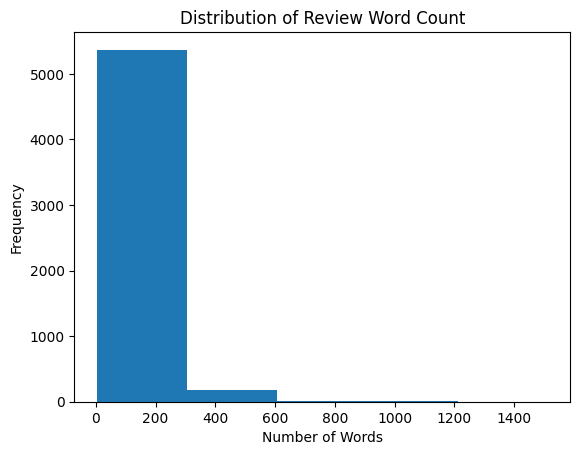

In [52]:
plt.hist(
    df["review_length"],
    bins=5
)

plt.title("Distribution of Review Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

## Remove Excessive Whitespace

In [53]:
df["review"] = (
    df["review"]
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

## Ensure String Type

In [54]:
df["review"].dtype

dtype('O')

## Generate Review ID

In [55]:
df.insert(
    0,
    "review_id",
    [f"RVW_{i:05d}" for i in range(1, len(df)+1)]
)

df.head()

,review_id,brand,product,username,rating,tanggal,review,review_length
0,RVW_00001,HMNS,Philea,J***a,5,3 bulan lalu,"Wanginya pas buat saya..elegant, ringan, seger...",145
1,RVW_00002,HMNS,Philea,Z***f,5,10 bulan lalu,Fix ini parfum hmns terbaik terenak terdebes. ...,247
2,RVW_00003,HMNS,Philea,F***m,5,7 bulan lalu,"produk sesuai deskripsi, produk berkualitas, h...",93
3,RVW_00004,HMNS,Philea,Q***z,5,3 minggu lalu,"pengiriman aman dan cepat, belanja dapet harga...",275
4,RVW_00005,HMNS,Philea,shabrina,5,10 bulan lalu,"packing aman banget, wangi ny bener2 se enakk ...",106


## Save Clean Dataset

In [ ]:
os.makedirs(
    f"{PROJECT_PATH}/data/interim",
    exist_ok=True
)

df.to_csv(
    f"{PROJECT_PATH}/data/interim/perfume_review_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [56]:
df.head()

,review_id,brand,product,username,rating,tanggal,review,review_length
0,RVW_00001,HMNS,Philea,J***a,5,3 bulan lalu,"Wanginya pas buat saya..elegant, ringan, seger...",145
1,RVW_00002,HMNS,Philea,Z***f,5,10 bulan lalu,Fix ini parfum hmns terbaik terenak terdebes. ...,247
2,RVW_00003,HMNS,Philea,F***m,5,7 bulan lalu,"produk sesuai deskripsi, produk berkualitas, h...",93
3,RVW_00004,HMNS,Philea,Q***z,5,3 minggu lalu,"pengiriman aman dan cepat, belanja dapet harga...",275
4,RVW_00005,HMNS,Philea,shabrina,5,10 bulan lalu,"packing aman banget, wangi ny bener2 se enakk ...",106


# Sprint 3 - Exploratory Text Analysis

**Objective**

This section aims to identify the main product aspects discussed by customers in perfume reviews through exploratory text analysis.

Instead of defining aspects based on assumptions, the aspect taxonomy will be derived from patterns observed in the review data.

The identified aspects will be used as the annotation schema for the subsequent LLM-assisted annotation process.

## Load Clean Data

In [57]:
cdf =  pd.read_csv("/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/data/interim/perfume_review_clean.csv")

pd.set_option(
    "display.max_colwidth",
    None
)

cdf.head()

,review_id,brand,product,username,rating,tanggal,review,review_length
0,RVW_00001,HMNS,Philea,J***a,5,3 bulan lalu,"Wanginya pas buat saya..elegant, ringan, seger..box kemasannya keren, botolnya juga simple elwgant, keren..gak nyangka aja ownernya alumni ITB..😄",145
1,RVW_00002,HMNS,Philea,Z***f,5,10 bulan lalu,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,247
2,RVW_00003,HMNS,Philea,F***m,5,7 bulan lalu,"produk sesuai deskripsi, produk berkualitas, harga bersaing, pengemasan baik, pengiriman baik",93
3,RVW_00004,HMNS,Philea,Q***z,5,3 minggu lalu,"pengiriman aman dan cepat, belanja dapet harga oke dan pastinya di jamin ori berawal dari nyobain bodymist nya dan suka banget aroma segarnya yang ringan dan nyari tau untuk produk parfum dan langsung pesan ternyata aroma nya beda tipis tipis aja untuk ketahanan belom cobain",275
4,RVW_00005,HMNS,Philea,shabrina,5,10 bulan lalu,"packing aman banget, wangi ny bener2 se enakk itu, apa lagi pas udh dry done nya🥹🥹🥹, the besttt pwwollllll",106


## Manual Review Exploration

In [58]:
sample_reviews = cdf.sample(
    50,
    random_state=42
)

sample_reviews[
    [
        "review_id",
        "review"
    ]
]

,review_id,review
2633,RVW_02634,"Sesuka ituu sama parfum saff n co ostara, wanginya cocok dan tahan lama walau terkena sinar matahari"
1550,RVW_01551,"Smells soo sooo soooo good like i expected. Wanginya sweet vanilla tp tetep ada hint muskynya suka bangett, dipake olahraga juga masi nyamannn. Good job hmns🫶🏻🥰 dapet bonus jugaa, kayanya karena ga dapet tester jd dapet semacdm card holder i guess?"
724,RVW_00725,aromanya enak. dpt 2 vial juga yg aromanya enak juga.. kemasan aman. pengiriman cepat. makasih
2788,RVW_02789,"Nice, wanginya nyaman banged, soft n cool"
468,RVW_00469,"wangi nya pas banget, gak terlalu berat."
5416,RVW_05417,"Kualitas produk: bagus sekali,packaging rapat dan barang sampain dengan selamat,wanginya juga cocok untuk sekolah"
2473,RVW_02474,"suka dgn wanginya, kalem yang tidak terlalu kalem . packing sangat mevvah"
4479,RVW_04480,"Kualitas produk: Sangat baik Nyampenya cepet dan kondisi barang baik, baunya enak banget, ketahanannya bisa 1 hari dibaju"
5118,RVW_05119,"Mykonos sih selalu lamggganan gua mah,, aromany kaya mil kita strawberry dan beneran enak utk anak sekolah tapi ketahanan kurang sih yak. Klo paradise Emg manis dan seenak itu Syg bgt ketahanan kurang juga Tpi msih worth to buy"
1864,RVW_01865,Super fast delivery! Packingnya bener2 secure jadi isinya juga sampai dengan selamat. Wanginya out of ordinary tapi tbh not really to my liking. Not your typical rose fragrance. Maybe I’ll grow into it?


**Observation**

The sampled reviews indicate that customers commonly discuss several dimensions of perfume quality, including fragrance characteristics, lasting duration, scent intensity, packaging quality, and perceived price value.

These initial observations were used as a reference for further quantitative text analysis.

## Word Frequency Analysis

In [59]:
from collections import Counter

text = " ".join(
    cdf["review"]
    .fillna("")
    .str.lower()
)

words = text.split()

word_freq = Counter(words)


freq_df = pd.DataFrame(
    word_freq.most_common(50),
    columns=[
        "word",
        "frequency"
    ]
)

freq_df.head(20)

,word,frequency
0,dan,1996
1,wanginya,1898
2,wangi,1700
3,nya,1493
4,yg,1327
5,enak,1250
6,banget,1102
7,di,1066
8,ini,1035
9,suka,959


**Observation**

The word frequency analysis shows that several high-frequency terms are related to customer opinions about perfume products, particularly fragrance-related terms such as "wangi", "wanginya", and "enak".

However, the most frequent words also contain common Indonesian stopwords and informal expressions, such as "dan", "di", "yang", "ini", and "aku". These words do not provide meaningful information for identifying product aspects.

Therefore, raw word frequency alone is insufficient for aspect discovery. Further analysis using contextual information from bigrams and domain-specific keyword mapping is required to identify meaningful customer evaluation aspects.

## Bigram Analysis

In [60]:
from sklearn.feature_extraction.text import CountVectorizer


vectorizer = CountVectorizer(
    ngram_range=(2,2),
    min_df=5
)


X = vectorizer.fit_transform(
    cdf["review"]
    .fillna("")
)


bigram_freq = pd.DataFrame(
    {
        "bigram": vectorizer.get_feature_names_out(),
        "frequency": X.sum(axis=0).A1
    }
)


bigram_freq.sort_values(
    "frequency",
    ascending=False
).head(20)

,bigram,frequency
1335,kualitas produk,672
2487,wangi nya,488
2245,tahan lama,468
2527,wanginya enak,420
868,enak banget,293
2200,suka banget,219
1953,saff co,205
1821,pengiriman cepat,202
2297,terima kasih,155
1977,sama wanginya,141


**Observation**

The bigram analysis provides more contextual information compared to individual word frequency. Several frequently occurring word combinations are directly related to perfume evaluation, such as "wangi nya", "tahan lama", "wanginya enak", and "kualitas produk".

These patterns indicate that customers mainly discuss fragrance characteristics and product performance when reviewing perfumes. In particular, phrases related to scent quality and durability provide initial evidence for important aspects such as Aroma and Longevity.

However, some frequent bigrams are related to transaction experiences rather than product attributes, such as "pengiriman cepat", "terima kasih", and "packing aman". These terms are less relevant for product-focused ABSA and should be separated from the aspect discovery process.

Therefore, bigram analysis confirms that customer reviews contain meaningful product-related expressions and supports the identification of candidate aspects for perfume evaluation.

## Keyword Mapping to Candidate Aspects

In [61]:
aspect_keywords = {

    "Aroma": [
        "wangi",
        "harum",
        "aroma",
        "fresh",
        "enak",
        "floral"
    ],

    "Longevity": [
        "tahan",
        "awet",
        "lama",
        "jam"
    ],

    "Projection": [
    "kecium",
    "nyebar",
    "semerbak",
    "jejak",
    "tercium",
    "nyengat",
    "soft",
    "strong"
    ],

    "Packaging": [
        "botol",
        "box",
        "kemasan"
    ],

    "Value for Money": [
        "harga",
        "worth",
        "mahal",
        "murah"
    ]
}

**Observation**

The identified keywords were grouped into five candidate aspects representing the main dimensions customers use when evaluating perfume products.

These aspects cover both product characteristics (Aroma, Longevity, Projection, Packaging) and customer value perception (Value for Money).

## Aspect Mention Frequency Analysis

In [62]:
aspect_frequency = {}

review_text = (
    df["review"]
    .fillna("")
    .str.lower()
)


for aspect, keywords in aspect_keywords.items():

    count = 0

    for keyword in keywords:

        count += review_text.str.contains(
            keyword,
            regex=False
        ).sum()

    aspect_frequency[aspect] = count


aspect_df = pd.DataFrame(
    aspect_frequency.items(),
    columns=[
        "Aspect",
        "Mention Count"
    ]
)


aspect_df.sort_values(
    "Mention Count",
    ascending=False
)

,Aspect,Mention Count
0,Aroma,5777
1,Longevity,2148
2,Projection,559
3,Packaging,504
4,Value for Money,390


**Observation**

The analysis shows that Aroma is the most frequently discussed aspect, followed by Longevity, Projection, Packaging, and Value for Money.

Although some aspects have lower mention frequencies, they were retained because they represent important evaluation dimensions in perfume purchasing decisions.

Therefore, the final aspect taxonomy selected for the ABSA annotation process consists of:

1. Aroma
2. Longevity
3. Projection
4. Packaging
5. Value for Money